In [13]:
import arviz as az
import os.path as op
import numpy as np

bids_folder = '/Users/mrenke/data/ds-stressrisk'
source_folder = op.join(bids_folder, 'derivatives', 'cogmodels')

idata = az.from_netcdf('/Users/mrenke/data/ds-stressrisk/derivatives/cogmodels/model-EU_3_trace.netcdf')


In [18]:
alphas = idata.posterior['alpha_mu'].to_dataframe()
regressors = alphas.reset_index()['alpha_regressors'].unique()
n_reg = len(regressors)

In [20]:
n_reg

4

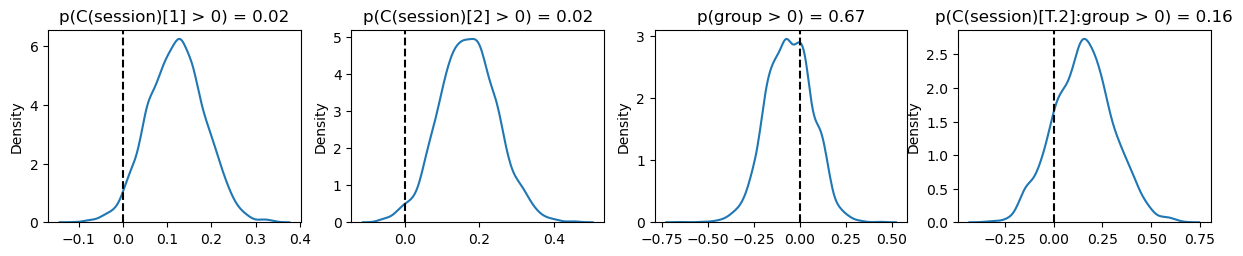

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

def softplus_np(x): return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0)

for count, reg in enumerate(regressors):
    a = alphas.xs(reg,0,'alpha_regressors') # 'C(session)[T.2]:group'
    ax = plt.subplot(1, 4, count+1)
    sns.kdeplot(a, legend=False)
    pval = np.round((a < 0.0).mean()[0],2)
    plt.title(f'p({reg} > 0) = {pval}')
    plt.axvline(0, c='black', ls='--')

plt.gcf().set_size_inches(15, 2.5)


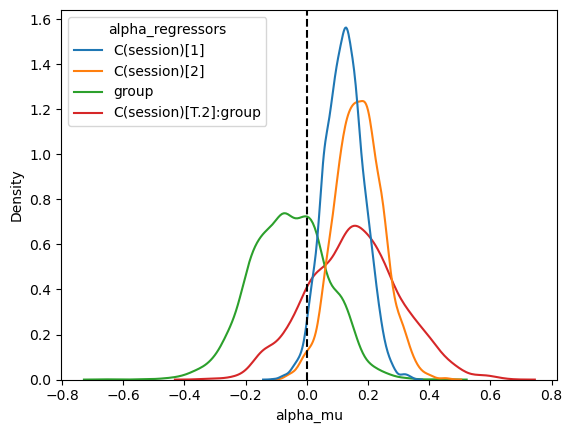

In [31]:
sns.kdeplot(data=alphas.reset_index(),x = 'alpha_mu', hue='alpha_regressors')
plt.axvline(0, c='black', ls='--')


In [7]:


full_NLC =  az.from_netcdf(op.join(source_folder, f'model-1_trace.netcdf'))
full_NLC_cps =  az.from_netcdf(op.join(source_folder, f'model-5_trace.netcdf')) # common prior shift = cps
#full_EU =  az.from_netcdf(op.join(source_folder, f'model-EU_3_trace.netcdf'))

compare_dict = {"NLC 1": full_NLC, "NLC common prior shift": full_NLC_cps} #,"EU": full_EU}

az.compare(compare_dict)

/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
NLC 1,0,-6068.542423,286.260652,0.000000,1.000000e+00,53.688490,0.000000,True,log
NLC common prior shift,1,-6083.570202,290.725246,15.027779,8.064660e-13,53.700917,5.328069,True,log


In [5]:


data1 =  az.from_netcdf(op.join(source_folder,  f'model-EU_1_trace.netcdf'))
data2 =  az.from_netcdf(op.join(source_folder,  f'model-EU_2_trace.netcdf'))
data3 = az.from_netcdf(op.join(source_folder,  f'model-EU_3_trace.netcdf'))

compare_dict = {"model 1": data1, "model 2": data2,"model 3": data3}

az.compare(compare_dict)

/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/mrenke/mambaforge/env

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
model 3,0,-6871.064534,189.813179,0.000000,0.650360,49.688854,0.000000,True,log
model 2,1,-6874.578916,189.053617,3.514382,0.294041,49.722136,4.017507,True,log
model 1,2,-7125.124604,102.428309,254.060071,0.055598,46.088945,23.230093,True,log
